# Sinhala Document OCR - Colab Baseline Pipeline

This notebook runs an **end-to-end baseline** for the Sinhala line-recognition
CRNN (CNN + BiLSTM + CTC) on a Colab **GPU** runtime. Each step maps directly onto
the project's `src/` modules so you can read the code alongside the notebook.

**Pipeline**
1. Clone the repository and install dependencies.
2. Install a Sinhala-capable font (Colab is Linux, so Windows fonts are absent).
3. Generate a synthetic Sinhala line dataset with a seeded train/val/test split.
4. Train the CRNN for a few epochs, logging train loss and validation CER, saving the best checkpoint.
5. Evaluate on the held-out test set (mean CER / WER) with qualitative examples.
6. Run an inference demo on a single line image.

> **Tip:** enable the GPU via *Runtime -> Change runtime type -> Hardware accelerator: GPU*.

## 1. Clone the project and install dependencies

We clone the public repository, `cd` into it, and install the Python requirements.
The notebook is **OS-aware**: it detects whether it is running inside Colab (Linux).

In [5]:
import os

REPO_URL = "https://github.com/Hellsgate96/sinhala-document-ocr-2026.git"
REPO_DIR = "sinhala-document-ocr-2026"
REPO_BRANCH = "master"

# Optional GitHub token (set the GITHUB_TOKEN env var) for private-repo access.
GITHUB_TOKEN = os.environ.get("GITHUB_TOKEN", "")
AUTH_URL = (
    REPO_URL.replace("https://", f"https://{GITHUB_TOKEN}@")
    if GITHUB_TOKEN else REPO_URL
)

# Detect Colab (Linux) vs. a local run.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except Exception:
    IN_COLAB = False
print("Running in Colab:", IN_COLAB)

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        # Clone the correct branch explicitly to avoid default-branch confusion.
        !git clone -b {REPO_BRANCH} {AUTH_URL} {REPO_DIR}
    else:
        # Repo already present: update it from the correct branch.
        !git -C {REPO_DIR} pull origin {REPO_BRANCH}

if os.path.isdir(REPO_DIR):
    %cd {REPO_DIR}
print("Working directory:", os.getcwd())

Running in Colab: True
Cloning into 'sinhala-document-ocr-2026'...
remote: Enumerating objects: 146, done.
remote: Counting objects: 100% (146/146), done.
remote: Compressing objects: 100% (121/121), done.
remote: Total 146 (delta 18), reused 67 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (146/146), 556.95 KiB | 2.83 MiB/s, done.
Resolving deltas: 100% (18/18), done.
/content/sinhala-document-ocr-2026
Working directory: /content/sinhala-document-ocr-2026


In [6]:
# torch / numpy / Pillow are usually preinstalled in Colab; this is quick if so.
!pip -q install -r requirements.txt
!pip -q install editdistance tqdm pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 71.9 MB/s eta 0:00:00


## 2. Install a Sinhala-capable font

The synthetic generator renders text with a TrueType font. Colab runs on Linux, so
the Windows default (`Nirmala.ttc`) does not exist. We install **Noto Sans Sinhala**
from the `fonts-noto-core` apt package, with a direct download as a robust fallback,
then locate the resulting `.ttf` on disk.

In [7]:
import glob

FONT_PATH = None
if IN_COLAB:
    # 1) Noto Sans Sinhala ships inside the fonts-noto-core apt package.
    !apt-get -qq update > /dev/null 2>&1
    !apt-get -qq install -y fonts-noto-core > /dev/null 2>&1 || true
    # 2) Robust fallback: download a static Noto Sans Sinhala TTF.
    os.makedirs("fonts", exist_ok=True)
    if not glob.glob("fonts/*Sinhala*.ttf"):
        !wget -q -O fonts/NotoSansSinhala-Regular.ttf "https://github.com/notofonts/sinhala/raw/main/fonts/NotoSansSinhala/hinted/ttf/NotoSansSinhala-Regular.ttf" || true

# Search common locations for a Sinhala-capable font file.
candidates = (
    glob.glob("/usr/share/fonts/**/*Sinhala*.ttf", recursive=True)
    + glob.glob("fonts/*Sinhala*.ttf")
    + ["C:/Windows/Fonts/Nirmala.ttc"]  # local Windows fallback
)
candidates = [c for c in candidates if os.path.isfile(c)]
assert candidates, "No Sinhala font found - re-run this cell or `apt-get install fonts-noto-core`."
FONT_PATH = candidates[0]
print("Using Sinhala font:", FONT_PATH)

Using Sinhala font: /usr/share/fonts/truetype/noto/NotoSansSinhala-Regular.ttf


## 3. Load the configuration

`configs/default.yaml` is the single source of truth for paths, image geometry,
synthetic-data settings and training hyper-parameters. We load it, point the
generator at the Colab font, and choose baseline dataset / training sizes.

In [8]:
import sys
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

from src.utils.common import load_config, configure_stdout_utf8, get_logger
configure_stdout_utf8()

cfg = load_config("configs/default.yaml")

# OS-aware: use the font we just installed.
cfg["synthetic"]["fonts"] = [FONT_PATH]

# Baseline sizes - tune these for longer runs.
NUM_SAMPLES = 10000     # first run: ~8k-12k lines
EPOCHS = 15
BATCH_SIZE = 64
OUT_DIR = cfg["paths"]["synthetic_dir"]   # data/synthetic

print("image height :", cfg["image"]["height"], "| max_width:", cfg["image"]["max_width"])
print("charset path :", cfg["paths"]["charset_path"])
print("output dir   :", OUT_DIR)

image height : 32 | max_width: 512
charset path : models/charset.json
output dir   : data/synthetic


## 4. Generate the synthetic dataset

`generate(...)` renders `NUM_SAMPLES` augmented line images, then writes
`all_labels.txt` plus the per-split `train_labels.txt` / `val_labels.txt` /
`test_labels.txt` (each row is `relative_image_path<TAB>transcript`). Vocabulary is
drawn from `sample_words.txt` and the form-field list `form_vocab.txt`. A `tqdm`
progress bar shows rendering progress.

In [9]:
from src.data.synthetic_generator import generate, load_word_lists

logger = get_logger("generate")
words = load_word_lists([cfg["paths"]["word_list"], cfg["paths"].get("form_vocab")],
                        warn=logger.warning)
print("Vocabulary entries:", len(words))

counts = generate(
    out_dir=OUT_DIR,
    num_samples=NUM_SAMPLES,
    font_paths=[FONT_PATH],
    font_sizes=cfg["synthetic"]["font_sizes"],
    words=words,
    min_words=cfg["synthetic"]["min_words"],
    max_words=cfg["synthetic"]["max_words"],
    augment=cfg["synthetic"]["augment"],
    split=cfg["synthetic"]["split"],
    seed=cfg["project"]["seed"],
    logger=logger,
    numeric_ratio=cfg["synthetic"]["numeric_ratio"],
    mixed_ratio=cfg["synthetic"]["mixed_ratio"],
)
print("Split counts:", counts)

20:15:39 | INFO    | generate | [fonts] using 1 font(s); 479 vocab entries; 10000 samples


Vocabulary entries: 479


render: 100%|██████████| 10000/10000 [04:07<00:00, 40.38it/s]
20:19:46 | INFO    | generate | [split] train: 7000 samples
20:19:46 | INFO    | generate | [split] val: 1500 samples
20:19:46 | INFO    | generate | [split] test: 1500 samples
20:19:46 | INFO    | generate | [done] wrote 10000 images to data/synthetic/images


Split counts: {'train': 7000, 'val': 1500, 'test': 1500}


### Preview a few generated lines

We register the Sinhala font with matplotlib so the transcripts render correctly in
the titles.

/tmp/ipykernel_3873/268035926.py:19: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Sinhala.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3873/268035926.py:19: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Sinhala.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3873/268035926.py:19: UserWarning: Glyph 78 (N) missing from font(s) Noto Sans Sinhala.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3873/268035926.py:19: UserWarning: Glyph 111 (o) missing from font(s) Noto Sans Sinhala.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3873/268035926.py:19: UserWarning: Glyph 65 (A) missing from font(s) Noto Sans Sinhala.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3873/268035926.py:19: UserWarning: Glyph 76 (L) missing from font(s) Noto Sans Sinhala.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Sinhala.
  fig.canvas.print_figure(bytes_io, **kw)


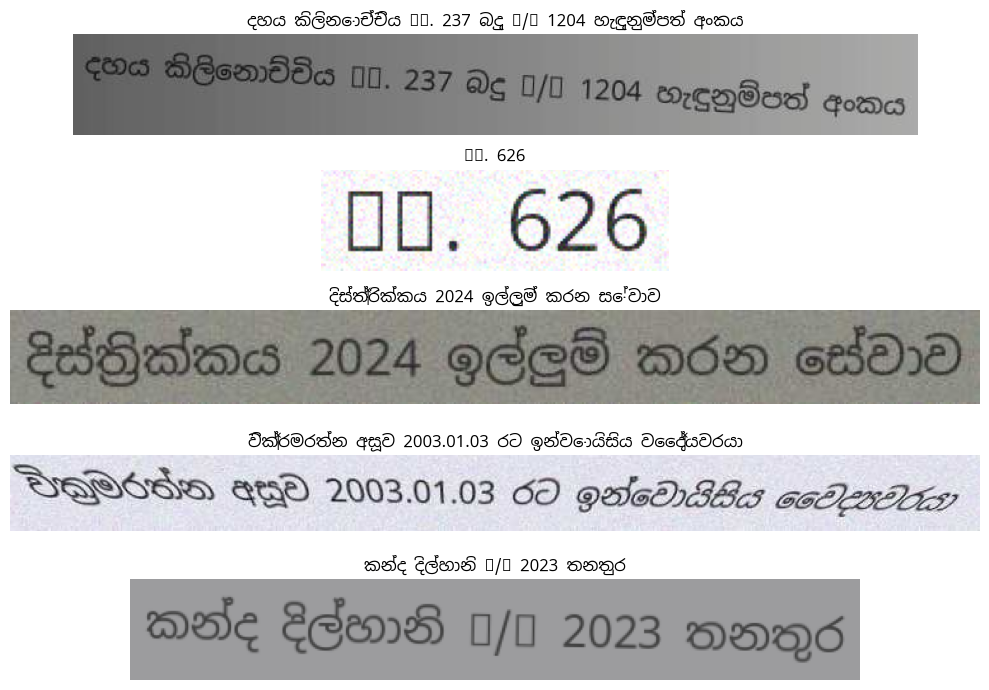

In [10]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from src.data.dataset import read_labels

try:
    if FONT_PATH.lower().endswith((".ttf", ".otf")):
        fm.fontManager.addfont(FONT_PATH)
        plt.rcParams["font.family"] = fm.FontProperties(fname=FONT_PATH).get_name()
except Exception as e:
    print("(font registration skipped:", e, ")")

rows = read_labels(os.path.join(OUT_DIR, "train_labels.txt"))
fig, axes = plt.subplots(5, 1, figsize=(10, 7))
for ax, (rel, text) in zip(axes, rows[:5]):
    ax.imshow(Image.open(os.path.join(OUT_DIR, rel)))
    ax.set_title(text, fontsize=12)
    ax.axis("off")
plt.tight_layout(); plt.show()

## 5. Train the CRNN baseline

`src/recognition/train.py` builds the shared `Charset` (saved next to the
checkpoints), trains with `torch.nn.CTCLoss`, logs **train loss** and **validation
CER** each epoch, and saves `crnn_best.pth` (lowest val CER) + `crnn_last.pth` to
`models/`. We pass config overrides on the command line.

In [11]:
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Training device:", DEVICE)

cmd = (
    f"python -m src.recognition.train --config configs/default.yaml "
    f"paths.synthetic_dir={OUT_DIR} train.epochs={EPOCHS} "
    f"train.batch_size={BATCH_SIZE} train.device={DEVICE}"
)
print(cmd)
!{cmd}

Training device: cuda
python -m src.recognition.train --config configs/default.yaml paths.synthetic_dir=data/synthetic train.epochs=15 train.batch_size=64 train.device=cuda
20:19:53 | INFO    | train | device = cuda
20:19:53 | INFO    | train | charset classes (incl. blank) = 225
20:20:29 | INFO    | train | epoch 001 | train_loss = 5.2228
20:20:32 | INFO    | train | epoch 001 | val CER = 1.0000 | val WER = 1.0000
20:20:33 | INFO    | train |   -> new best CER 1.0000 (saved crnn_best.pth)
20:21:02 | INFO    | train | epoch 002 | train_loss = 3.8712
20:21:05 | INFO    | train | epoch 002 | val CER = 1.0000 | val WER = 1.0000
20:21:36 | INFO    | train | epoch 003 | train_loss = 3.4168
20:21:39 | INFO    | train | epoch 003 | val CER = 0.8882 | val WER = 1.0000
20:21:39 | INFO    | train |   -> new best CER 0.8882 (saved crnn_best.pth)
20:22:10 | INFO    | train | epoch 004 | train_loss = 3.0064
20:22:14 | INFO    | train | epoch 004 | val CER = 0.8701 | val WER = 1.0004
20:22:14 | INFO

## 6. Evaluate on the held-out test set

We load the best checkpoint and the saved charset, build a test `DataLoader`, and
compute corpus **CER** and **WER** with `evaluate_model(...)`.

In [12]:
from src.charset import Charset
from src.data.dataset import build_dataloader
from src.recognition.model import build_crnn
from src.evaluation.metrics import evaluate_model
from src.utils.common import load_checkpoint, get_device

charset = Charset.load(cfg["paths"]["charset_path"])
device = get_device(DEVICE)
model = build_crnn(charset.num_classes, cfg.get("model"),
                   in_channels=cfg["image"]["channels"]).to(device)
load_checkpoint("models/crnn_best.pth", model, map_location=str(device))
model.eval()

test_loader = build_dataloader(
    os.path.join(OUT_DIR, "test_labels.txt"), charset,
    batch_size=cfg["train"]["batch_size"], height=cfg["image"]["height"],
    max_width=cfg["image"]["max_width"], channels=cfg["image"]["channels"],
    shuffle=False, num_workers=2)

report = evaluate_model(model, test_loader, charset, device=device, measure_cpu_time=False)
print(f"TEST  samples={report['num_samples']}  CER={report['cer']:.4f}  WER={report['wer']:.4f}")

TEST  samples=1500  CER=0.0561  WER=0.2106


### Qualitative predictions (image + ground truth + prediction)

/tmp/ipykernel_3873/3970300445.py:10: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Sinhala.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3873/3970300445.py:10: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Sinhala.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3873/3970300445.py:10: UserWarning: Glyph 71 (G) missing from font(s) Noto Sans Sinhala.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3873/3970300445.py:10: UserWarning: Glyph 84 (T) missing from font(s) Noto Sans Sinhala.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3873/3970300445.py:10: UserWarning: Glyph 80 (P) missing from font(s) Noto Sans Sinhala.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3873/3970300445.py:10: UserWarning: Glyph 82 (R) missing from font(s) Noto Sans Sinhala.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3873/3970300445.py:10: UserWarning: Glyph 69 (E) missing from font(s) Noto Sans Sinhala.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3873/3970300445.py:10: U

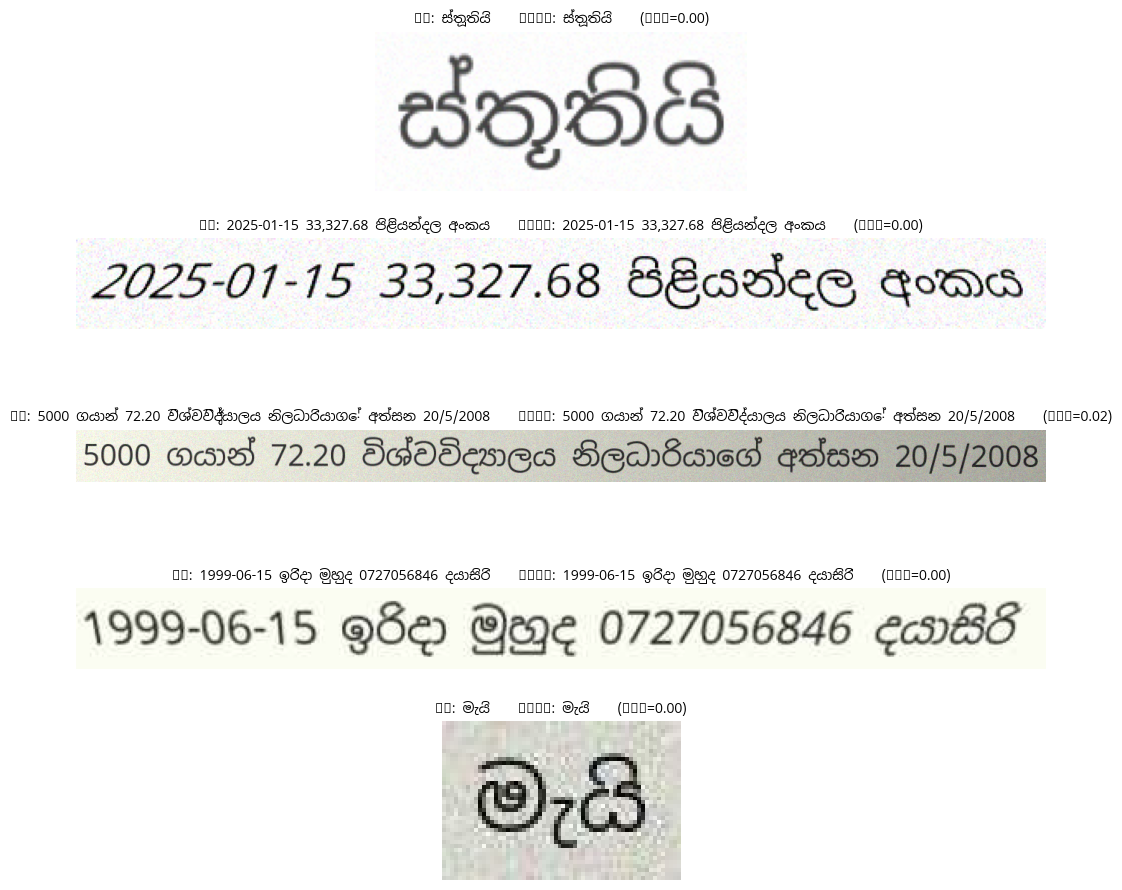

In [13]:
test_rows = read_labels(os.path.join(OUT_DIR, "test_labels.txt"))
n = min(5, len(test_rows))
fig, axes = plt.subplots(n, 1, figsize=(10, 1.8 * n))
if n == 1:
    axes = [axes]
for ax, (rel, _), s in zip(axes, test_rows[:n], report["per_sample"][:n]):
    ax.imshow(Image.open(os.path.join(OUT_DIR, rel)))
    ax.set_title(f"GT: {s['ref']}    PRED: {s['hyp']}    (CER={s['cer']:.2f})", fontsize=10)
    ax.axis("off")
plt.tight_layout(); plt.show()

## 7. Optional: quick check on a synthetic test line

If you want a one-line sanity check before trying your own photos, run the cell below.
It runs `predict_image(...)` on a single line from the synthetic **test** split (ground
truth is known). For a full document workflow (upload → preprocess → line detection → OCR),
continue to **Section 8**.


In [ ]:
from IPython.display import display
from PIL import Image
from src.recognition.predict import predict_image

sample_rel, sample_gt = read_labels(os.path.join(OUT_DIR, "test_labels.txt"))[0]
sample_path = os.path.join(OUT_DIR, sample_rel)
pred = predict_image(model, charset, sample_path,
                     cfg["image"]["height"], cfg["image"]["max_width"],
                     cfg["image"]["channels"], device)
print("Image       :", sample_path)
print("Ground truth:", sample_gt)
print("Prediction  :", pred)
display(Image.open(sample_path))


## 8. Test on your own uploaded image

Upload a photo or scan of a Sinhala document (form, invoice, ID, handwritten note, etc.).

**Pipeline:** upload → optional preprocessing → text-line detection → CRNN recognition per line → results.

**Checkpoint:** this section loads `models/crnn_best.pth` and `models/charset.json` produced in **Section 5**.
If you have not trained yet, run training first, or set `CHECKPOINT_PATH` / `CHARSET_PATH` to a copy you saved
(for example from Google Drive).

**Tips:** printed pages with clear contrast work best with the OpenCV line detector. If detection finds no lines
(a common case for a photo that is already a single line), the notebook treats the whole preprocessed image as one line.


In [ ]:
import glob
import os

import cv2
import matplotlib.pyplot as plt

UPLOAD_DIR = os.path.join(cfg["paths"]["data_dir"], "uploads")
os.makedirs(UPLOAD_DIR, exist_ok=True)

UPLOADED_IMAGE_PATH = None

if IN_COLAB:
    from google.colab import files

    uploaded = files.upload()
    if not uploaded:
        raise ValueError("No file selected. Run the cell again and choose an image.")
    fname = next(iter(uploaded))
    UPLOADED_IMAGE_PATH = os.path.join(UPLOAD_DIR, fname)
    with open(UPLOADED_IMAGE_PATH, "wb") as f:
        f.write(uploaded[fname])
else:
    UPLOADED_IMAGE_PATH = globals().get("LOCAL_UPLOAD_PATH", "").strip()
    if not UPLOADED_IMAGE_PATH:
        for ext in ("*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"):
            hits = sorted(glob.glob(os.path.join(UPLOAD_DIR, ext)))
            if hits:
                UPLOADED_IMAGE_PATH = hits[-1]
                break
    if not UPLOADED_IMAGE_PATH or not os.path.isfile(UPLOADED_IMAGE_PATH):
        print(
            "Local mode: set LOCAL_UPLOAD_PATH = r'C:\\path\\to\\document.jpg' "
            "in a cell above, or place an image in data/uploads/, then re-run this cell."
        )
    else:
        print("Using local file:", UPLOADED_IMAGE_PATH)

if UPLOADED_IMAGE_PATH and os.path.isfile(UPLOADED_IMAGE_PATH):
    print("Saved to:", UPLOADED_IMAGE_PATH)
    bgr = cv2.imread(UPLOADED_IMAGE_PATH)
    if bgr is None:
        raise ValueError(f"Could not read image: {UPLOADED_IMAGE_PATH}")
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 8))
    plt.imshow(rgb)
    plt.title("Uploaded document")
    plt.axis("off")
    plt.show()


In [ ]:
import os
import tempfile

import cv2
import torch

from src.charset import Charset
from src.detection.text_detection import OpenCVLineDetector, crop_lines, draw_boxes
from src.preprocessing.preprocess import preprocess_document
from src.recognition.model import build_crnn
from src.recognition.predict import predict_image
from src.utils.common import configure_stdout_utf8, get_device, load_checkpoint

configure_stdout_utf8()

SHOW_PREPROCESSED = True
RUN_PREPROCESS = True
MIN_LINE_HEIGHT = cfg["detection"]["min_line_height"]
MIN_LINE_WIDTH = cfg["detection"]["min_line_width"]
DILATE_KERNEL = tuple(cfg["detection"]["dilate_kernel"])

CHECKPOINT_PATH = os.path.join(cfg["paths"]["models_dir"], "crnn_best.pth")
CHARSET_PATH = cfg["paths"]["charset_path"]

if not UPLOADED_IMAGE_PATH or not os.path.isfile(UPLOADED_IMAGE_PATH):
    raise RuntimeError("Run the upload cell above first (Section 8).")

if not os.path.isfile(CHECKPOINT_PATH):
    raise FileNotFoundError(
        "Train the model first (Section 5) or place crnn_best.pth in models/"
    )
if not os.path.isfile(CHARSET_PATH):
    raise FileNotFoundError(
        f"Charset file not found: {CHARSET_PATH}. Run training (Section 5) first."
    )

_device = globals().get("device")
if _device is None:
    _device = get_device(globals().get("DEVICE", "auto"))

_charset = Charset.load(CHARSET_PATH)
_model = build_crnn(
    _charset.num_classes,
    cfg.get("model"),
    in_channels=cfg["image"]["channels"],
).to(_device)
load_checkpoint(CHECKPOINT_PATH, _model, map_location=str(_device))
_model.eval()

page_bgr = cv2.imread(UPLOADED_IMAGE_PATH, cv2.IMREAD_COLOR)
if page_bgr is None:
    raise ValueError(f"Could not read {UPLOADED_IMAGE_PATH}")

if RUN_PREPROCESS:
    page_for_det = preprocess_document(page_bgr)
else:
    page_for_det = cv2.cvtColor(page_bgr, cv2.COLOR_BGR2GRAY)

detector = OpenCVLineDetector(
    dilate_kernel=DILATE_KERNEL,
    min_line_height=int(MIN_LINE_HEIGHT),
    min_line_width=int(MIN_LINE_WIDTH),
)
boxes = detector.detect(page_for_det)
if not boxes:
    h, w = page_for_det.shape[:2]
    boxes = [(0, 0, w, h)]
    print("[info] No lines detected —- using the full image as one line.")

line_crops = crop_lines(page_for_det, boxes, padding=2)
annotated_bgr = draw_boxes(page_bgr, boxes)
annotated = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

h_img, mw, ch = cfg["image"]["height"], cfg["image"]["max_width"], cfg["image"]["channels"]
upload_predictions = []

with torch.no_grad():
    for i, crop in enumerate(line_crops):
        with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tmp:
            tmp_path = tmp.name
        cv2.imwrite(tmp_path, crop)
        try:
            text = predict_image(_model, _charset, tmp_path, h_img, mw, ch, _device)
        finally:
            os.remove(tmp_path)
        upload_predictions.append({"line": i + 1, "text": text, "crop": crop.copy()})

full_transcription = "\n".join(p["text"] for p in upload_predictions)
print("--- Full document transcription (copy-friendly) ---")
print(full_transcription)
print("--- end ---")

def _configure_matplotlib_sinhala_font():
    import matplotlib.pyplot as plt
    from matplotlib import font_manager

    font_path = globals().get("FONT_PATH")
    if not font_path or not os.path.isfile(font_path):
        return
    try:
        if font_path.lower().endswith((".ttf", ".otf", ".ttc")):
            font_manager.fontManager.addfont(font_path)
            plt.rcParams["font.family"] = font_manager.FontProperties(fname=font_path).get_name()
    except Exception as exc:
        print("(matplotlib Sinhala font skipped:", exc, ")")


_configure_matplotlib_sinhala_font()

if SHOW_PREPROCESSED:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(cv2.cvtColor(page_bgr, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original upload")
    axes[0].axis("off")
    axes[1].imshow(page_for_det, cmap="gray")
    axes[1].set_title("Preprocessed (for detection)")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()


In [ ]:
import os
import matplotlib.pyplot as plt

def _configure_matplotlib_sinhala_font():
    import matplotlib.pyplot as plt
    from matplotlib import font_manager

    font_path = globals().get("FONT_PATH")
    if not font_path or not os.path.isfile(font_path):
        return
    try:
        if font_path.lower().endswith((".ttf", ".otf", ".ttc")):
            font_manager.fontManager.addfont(font_path)
            plt.rcParams["font.family"] = font_manager.FontProperties(fname=font_path).get_name()
    except Exception as exc:
        print("(matplotlib Sinhala font skipped:", exc, ")")


_configure_matplotlib_sinhala_font()


print(f"{'Line':>4}  {'Ground truth':<16}  Predicted")
print("-" * 60)
for row in upload_predictions:
    print(f"{row['line']:>4}  {'(N/A)':<16}  {row['text']}")

plt.figure(figsize=(10, 8))
plt.imshow(annotated)
plt.title("Detected text lines (red boxes)")
plt.axis("off")
plt.show()

n = len(upload_predictions)
if n:
    fig, axes = plt.subplots(n, 1, figsize=(10, max(2, 1.6 * n)))
    if n == 1:
        axes = [axes]
    for ax, row in zip(axes, upload_predictions):
        ax.imshow(row["crop"], cmap="gray")
        ax.set_title(f"Line {row['line']}: {row['text']}", fontsize=11)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


## Optional: persist the model to Google Drive

Uncomment to mount Drive and copy the best checkpoint + charset so they survive the
Colab session.

In [16]:
from google.colab import drive
drive.mount('/content/drive')
import shutil
os.makedirs('/content/drive/MyDrive/sinhala_ocr', exist_ok=True)
shutil.copy('models/crnn_best.pth', '/content/drive/MyDrive/sinhala_ocr/')
shutil.copy('models/charset.json', '/content/drive/MyDrive/sinhala_ocr/')
print("Uncomment the lines above to save the model + charset to Google Drive.")

Mounted at /content/drive
Uncomment the lines above to save the model + charset to Google Drive.
